In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import sklearn

In [5]:
# df = pd.read_csv('./diabetes_prediction_dataset.csv')


import kagglehub
path = kagglehub.dataset_download("iammustafatz/diabetes-prediction-dataset")
df = pd.read_csv(f"{path}/diabetes_prediction_dataset.csv")
print("Path to dataset files:", path)

/Users/cxnner05/Documents/uni_notes/year 3/lab-ml/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /Users/cxnner05/.cache/kagglehub/datasets/iammustafatz/diabetes-prediction-dataset/versions/1


### Data Cleaning

<small>Handling columns </small>

In [6]:
df.shape

(100000, 9)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [8]:
df.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes'],
      dtype='object')

Handle Redundant Columns

In [9]:
compression_map = {
    "never": "Never",
    "No Info": "Unknown",
    "current": "Current",
    "former": "Past",
    "ever": "Past",
    "not current": "Past"
}

# assumes ever meant that the person had smoked at some point in the past

df["smoking_history"] = df["smoking_history"].apply(lambda x: compression_map[x] if x in compression_map else "Unknown")


Dropping duplicates

In [10]:
df.duplicated().sum()

np.int64(4032)

In [11]:
df.drop_duplicates(inplace=True)

Handling Nulls

In [12]:
df.isnull().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 95968 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   gender               95968 non-null  object 
 1   age                  95968 non-null  float64
 2   hypertension         95968 non-null  int64  
 3   heart_disease        95968 non-null  int64  
 4   smoking_history      95968 non-null  object 
 5   bmi                  95968 non-null  float64
 6   HbA1c_level          95968 non-null  float64
 7   blood_glucose_level  95968 non-null  int64  
 8   diabetes             95968 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 7.3+ MB


### Checking Columns

In [14]:
non_numerical_cols = df.select_dtypes(exclude=['number']).columns
non_numerical_cols

Index(['gender', 'smoking_history'], dtype='object')

In [15]:
print('Unique values in non-numerical columns:')
print(non_numerical_cols[0], ':')
print('-----------------------------------')
print(df[non_numerical_cols[0]].unique())
print('-----------------------------------')
print('\n')
print(non_numerical_cols[1], ':')
print('-----------------------------------')
print(df[non_numerical_cols[1]].unique())

Unique values in non-numerical columns:
gender :
-----------------------------------
['Female' 'Male' 'Other']
-----------------------------------


smoking_history :
-----------------------------------
['Never' 'Unknown' 'Current' 'Past']


In [16]:
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,Never,25.19,6.6,140,0
1,Female,54.0,0,0,Unknown,27.32,6.6,80,0
2,Male,28.0,0,0,Never,27.32,5.7,158,0
3,Female,36.0,0,0,Current,23.45,5.0,155,0
4,Male,76.0,1,1,Current,20.14,4.8,155,0


### Outlier Analysis

<small> Although nulls were removed, no one can really say the data is 'correct' on row level </small>

In [17]:
categorical_cols = df.select_dtypes(include=['object']).columns
categorical_cols

Index(['gender', 'smoking_history'], dtype='object')

Visualization of Skewness

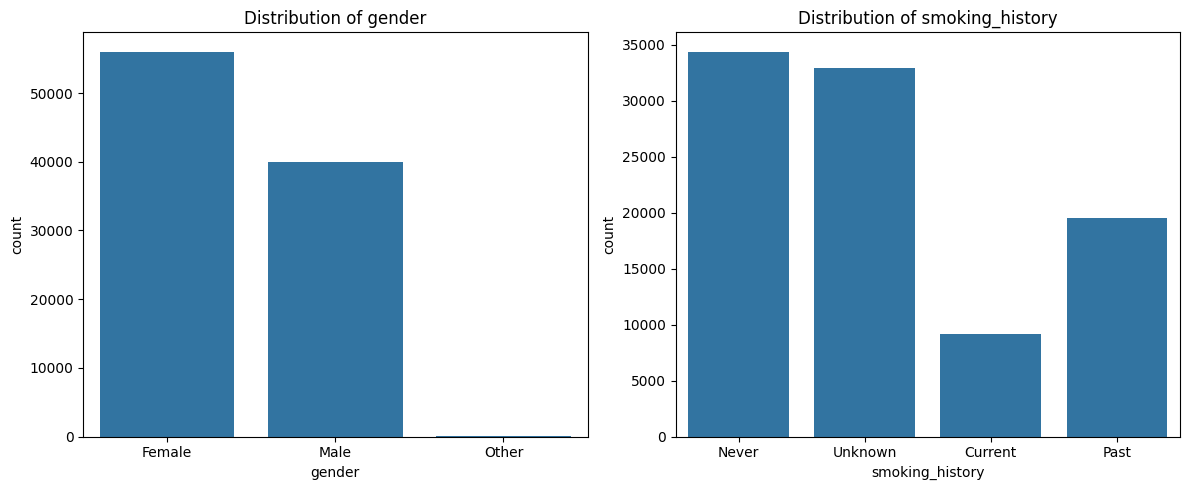

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, col in zip(axes, categorical_cols):
    sns.countplot(data=df, x=col,ax=ax)
    ax.set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

In [19]:
numerical_cols = df.select_dtypes(include=['number']).columns[:-1]
numerical_cols

Index(['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level',
       'blood_glucose_level'],
      dtype='object')

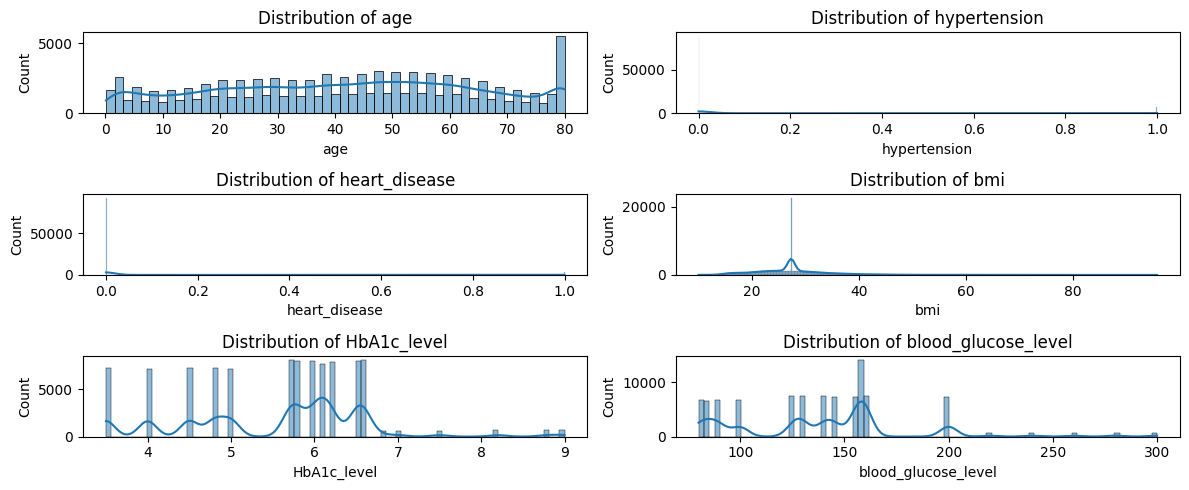

In [20]:
fig, axes = plt.subplots(len(numerical_cols)//2, 2, figsize=(12, 5))
for ax, col in zip(axes.flatten(), numerical_cols):
    sns.histplot(data=df, x=col,ax=ax, kde=True) 
    ax.set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

Skewness of Columns

In [21]:
for col in categorical_cols:
    print("Skewness of", col, ":", df[col].value_counts().skew())
 
    # interpretation 
    if df[col].value_counts().skew() > 1:
        print("The distribution of", col, "is highly skewed.")
    elif df[col].value_counts().skew() > 0.5:
        print("The distribution of", col, "is moderately skewed.")
    elif df[col].value_counts().skew() > -0.5:
        print("The distribution of", col, "is approximately symmetric.")
    elif df[col].value_counts().skew() > -1:
        print("The distribution of", col, "is moderately skewed (negative).")
    else:
        print("The distribution of", col, "is highly skewed (negative).")
    print("\n")
    
for col in numerical_cols:
    print("Skewness of", col, ":", df[col].skew())
    
    # interpretation
    if df[col].skew() > 1:
        print("The distribution of", col, "is highly skewed.")
    elif df[col].skew() > 0.5:
        print("The distribution of", col, "is moderately skewed.")
    elif df[col].skew() > -0.5:
        print("The distribution of", col, "is approximately symmetric.")
    elif df[col].skew() > -1:
        print("The distribution of", col, "is moderately skewed (negative).")
    else:
        print("The distribution of", col, "is highly skewed (negative).")
    print("\n")

Skewness of gender : -1.14245114904853
The distribution of gender is highly skewed (negative).


Skewness of smoking_history : -0.5894881364889462
The distribution of smoking_history is moderately skewed (negative).


Skewness of age : -0.06220364949722827
The distribution of age is approximately symmetric.


Skewness of hypertension : 3.1547370339523413
The distribution of hypertension is highly skewed.


Skewness of heart_disease : 4.638820907805003
The distribution of heart_disease is highly skewed.


Skewness of bmi : 1.0228018948003708
The distribution of bmi is highly skewed.


Skewness of HbA1c_level : -0.0543352976607336
The distribution of HbA1c_level is approximately symmetric.


Skewness of blood_glucose_level : 0.8370920691741721
The distribution of blood_glucose_level is moderately skewed.




Visualization of Correlation of Columns

In [22]:
numerical_cols_w_target = numerical_cols.tolist() + ['diabetes']
numerical_cols_w_target

['age',
 'hypertension',
 'heart_disease',
 'bmi',
 'HbA1c_level',
 'blood_glucose_level',
 'diabetes']

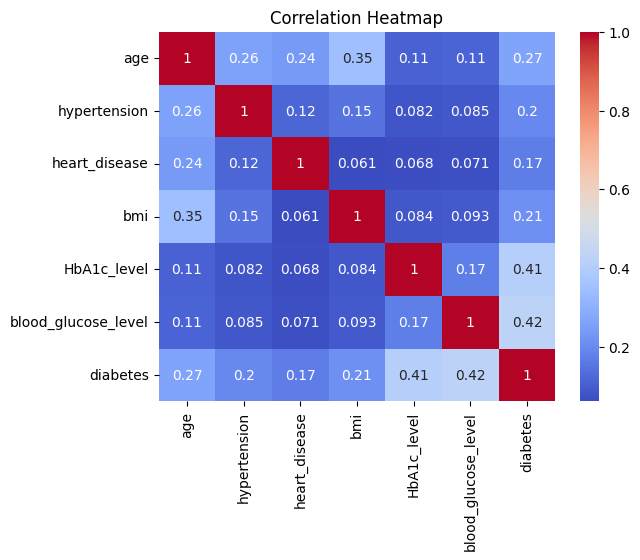

In [23]:
sns.heatmap(df[numerical_cols_w_target].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

### Boxplots and Removing Outliers

In [24]:
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,Never,25.19,6.6,140,0
1,Female,54.0,0,0,Unknown,27.32,6.6,80,0
2,Male,28.0,0,0,Never,27.32,5.7,158,0
3,Female,36.0,0,0,Current,23.45,5.0,155,0
4,Male,76.0,1,1,Current,20.14,4.8,155,0


Clean Function

In [25]:
def remove_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    clean_data = data[(data[column] >= lower_bound) & (data[column] <= upper_bound)]
    return clean_data


Get Range Function

In [26]:
def show_bounds(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    print("lower bound", lower_bound)
    print("upper bound", upper_bound)   

Basis

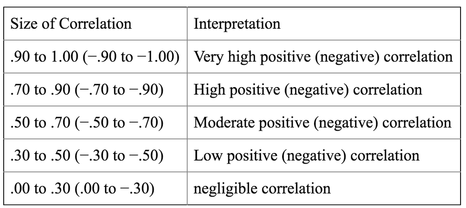

Diabetes and Age (0.27) negligible correlation

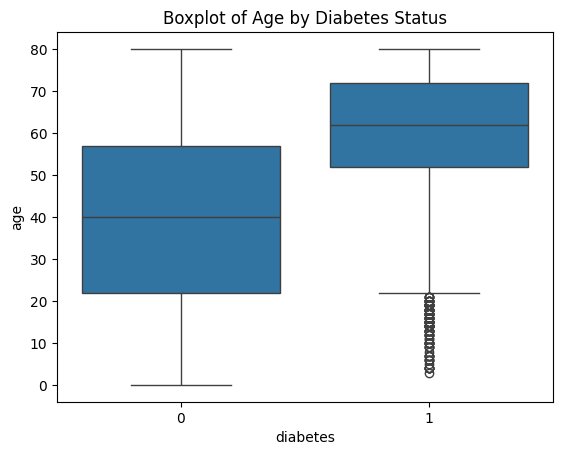

Shows that older people have higher chances of diabetes, but outliers are present.


In [27]:
sns.boxplot(x='diabetes', y='age', data=df)
plt.title('Boxplot of Age by Diabetes Status')
plt.show()
print("Shows that older people have higher chances of diabetes, but outliers are present.")

Diabetes and BMI(0.21)negligible correlation

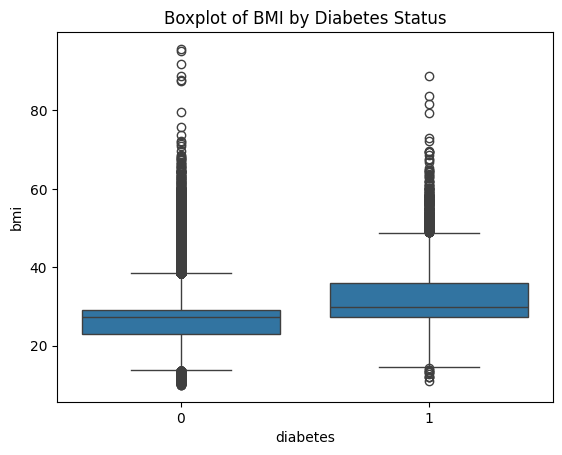

Shows that higher BMI is associated with diabetes, but outliers are present.


In [28]:
sns.boxplot(data=df, x='diabetes', y='bmi')
plt.title('Boxplot of BMI by Diabetes Status')
plt.show()
print("Shows that higher BMI is associated with diabetes, but outliers are present.")

Diabetes and HbA1c(0.41) Low Positive Correlation

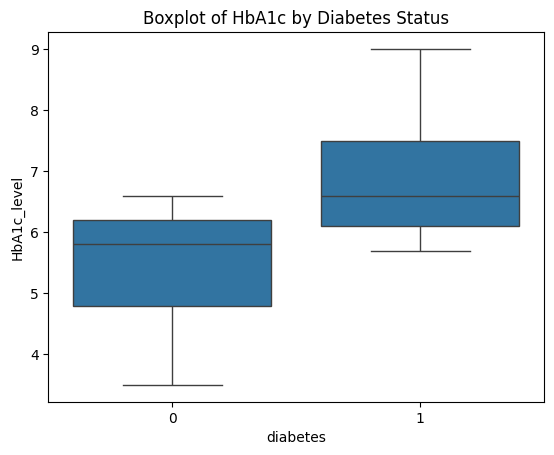

Shows that higher HbA1c levels are associated with diabetes. No significant outliers observed.


In [29]:
sns.boxplot(x='diabetes', y='HbA1c_level', data=df)
plt.title('Boxplot of HbA1c by Diabetes Status')
plt.show()
print("Shows that higher HbA1c levels are associated with diabetes. No significant outliers observed.")

Diabetes and Glucose Level(0.42) Low Positive Correlation

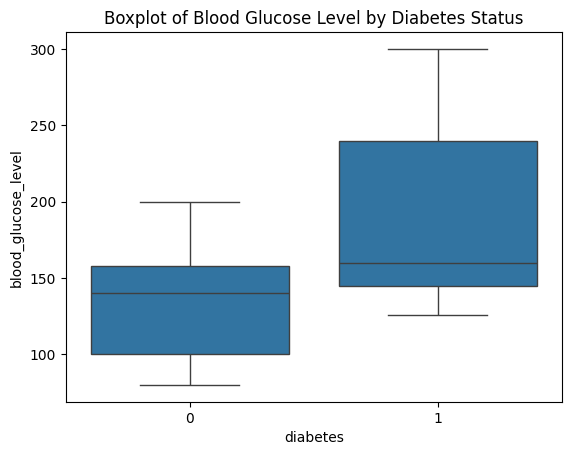

Shows that higher blood glucose levels are associated with diabetes. No significant outliers observed.


In [30]:
sns.boxplot(data=df, x='diabetes', y='blood_glucose_level')
plt.title('Boxplot of Blood Glucose Level by Diabetes Status')
plt.show()
print("Shows that higher blood glucose levels are associated with diabetes. No significant outliers observed.")

### Removal, Correction and Flagging of Outliers

<small> I've found questionable data in this data set but have chosen to use 'flags' instead to handle the unlikely values.Note that even when outliers are removed for both age and bmi that outliers are still present when grouped by diabetic or not suggesting that these values show little correlation with diabetes </small>

Check Data for Invalid Outliers on Age

In [31]:
df[(df['age'] <= 20)].min()


gender                  Female
age                       0.08
hypertension                 0
heart_disease                0
smoking_history        Current
bmi                      10.01
HbA1c_level                3.5
blood_glucose_level         80
diabetes                     0
dtype: object

<small> One must know that age cannot be a decimal, so there are erroneous data present</small>

In [32]:
show_bounds(df, 'age')

lower bound -28.5
upper bound 111.5


<small> To minimize the loss of data,  flag improbable ages </small>

In [33]:
df = remove_outliers(df, 'age')
df['age_flagged'] = df['age'].apply(lambda x: 1 if x < 5 or x != int(x) else 0)
df = df[df['age'] >= 1]

Check Data for Invalid Outliers on BMI

In [34]:
df[df['bmi'] > 40].max()

gender                    Male
age                       80.0
hypertension                 1
heart_disease                1
smoking_history        Unknown
bmi                      95.69
HbA1c_level                9.0
blood_glucose_level        300
diabetes                     1
age_flagged                  1
dtype: object

In [35]:
df[df['bmi'] > 20].min()

gender                  Female
age                        1.0
hypertension                 0
heart_disease                0
smoking_history        Current
bmi                      20.01
HbA1c_level                3.5
blood_glucose_level         80
diabetes                     0
age_flagged                  0
dtype: object

In [36]:
show_bounds(df, 'bmi')

lower bound 13.939999999999996
upper bound 39.540000000000006


In [37]:
df = remove_outliers(df, 'bmi')

Dealing with weird data on Smoking History

<small>This assumes that kids that are less than 8 might not be currently seeking out smoking, you must flag this data </small>

In [38]:
df.loc[(df['age'] < 5) & (df['smoking_history'] == "Current"), 'smoking_history'] = "Unknown"

In [39]:
df[df['age'] <= 5][['age', 'smoking_history']]

,age,smoking_history
21,5.00,Unknown
24,4.00,Unknown
35,5.00,Unknown
41,5.00,Unknown
49,3.00,Unknown
...,...,...
99882,3.00,Unknown
99906,3.00,Unknown
99916,1.48,Unknown
99940,2.00,Unknown


### Feature Engineering

<small>Take into Account that although Age and BMI might not be correlated on their own and we need to add feature interactions between them in order to see their significance in diabeters, for example, younger people wth diabetes are outliers but we need to check their glucose_level and their hb1Ac </small>

Breaking down Glucose and Hb1AC

In [40]:
median_hbA1c = df['HbA1c_level'].median()
median_gluc_level = df['blood_glucose_level'].median()

print("Median Glucose Level: ", median_gluc_level)
print("Median Hb1AC Level: ", median_hbA1c)

df_feat = df.copy()
df_feat['elevated_glucose'] = df_feat.apply(lambda x: 1 if x['blood_glucose_level'] > median_gluc_level else 0, axis=1)
df_feat['elevated_hbA1c'] = df_feat.apply(lambda x: 1 if x['HbA1c_level'] > median_hbA1c else 0, axis=1)

df_feat[df_feat['age'] <=20][['age', 'elevated_glucose', 'elevated_hbA1c']]
df_feat.head()

Median Glucose Level:  140.0
Median Hb1AC Level:  5.8


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes,age_flagged,elevated_glucose,elevated_hbA1c
0,Female,80.0,0,1,Never,25.19,6.6,140,0,0,0,1
1,Female,54.0,0,0,Unknown,27.32,6.6,80,0,0,0,1
2,Male,28.0,0,0,Never,27.32,5.7,158,0,0,1,0
3,Female,36.0,0,0,Current,23.45,5.0,155,0,0,1,0
4,Male,76.0,1,1,Current,20.14,4.8,155,0,0,1,0


<small>Data shows high blood glucose levels and HBA1c even if the age is low, when young people with diabetes </small>

Breaking down age based on seniority

<small> One can use the OrdinalEncoder of Sklearn to convert the values, underweight, normal, and overweight to 0,1,2 but to make things already numberical use an apply to set those values </small>

In [41]:

child = 12 # define age threshold for children
teenager = 13 # define age threshold for teenagers
adult = 20 # define age threshold for adults
senior =60 # define age threshold for seniors

# apply ordinal encoding based on age groups

df['age_group'] = df['age'].apply(lambda x: 0 if x <= child else 1 if x <= teenager else 2 if x <= adult else 3 if x < senior else 4)


Breaking down age based on weight

In [42]:
df_feat[df_feat['bmi'] <20].min()

gender                  Female
age                        1.0
hypertension                 0
heart_disease                0
smoking_history        Current
bmi                      13.94
HbA1c_level                3.5
blood_glucose_level         80
diabetes                     0
age_flagged                  0
elevated_glucose             0
elevated_hbA1c               0
dtype: object

In [43]:
median_bmi = df['bmi'].median()
print("Median BMI: ", median_bmi)

Median BMI:  27.32


In [44]:
df_feat['weight_class'] = df_feat.apply(lambda x: 2 if x['bmi'] > median_bmi else 0 if x['bmi'] < median_bmi else 1, axis=1)
df_feat[(df_feat['diabetes'] == 1) & ((df_feat['bmi'] < median_bmi) | (df_feat['bmi'] > median_bmi)) ][['age', 'bmi','weight_class', 'diabetes']]

,age,bmi,weight_class,diabetes
6,44.0,19.31,0,1
40,73.0,25.91,0,1
55,50.0,37.16,2,1
87,36.0,32.27,2,1
125,77.0,31.70,2,1
...,...,...,...,...
99935,65.0,33.55,2,1
99938,55.0,30.42,2,1
99957,61.0,34.45,2,1
99962,58.0,38.31,2,1


In [45]:
df_feat.groupby('weight_class')['diabetes'].sum()

weight_class
0    1669
1    1513
2    4029
Name: diabetes, dtype: int64

<small>Clearly shows that people overweight have a higher chance of having diabetes </small>

In [46]:
df_feat

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes,age_flagged,elevated_glucose,elevated_hbA1c,weight_class
0,Female,80.0,0,1,Never,25.19,6.6,140,0,0,0,1,0
1,Female,54.0,0,0,Unknown,27.32,6.6,80,0,0,0,1,1
2,Male,28.0,0,0,Never,27.32,5.7,158,0,0,1,0,1
3,Female,36.0,0,0,Current,23.45,5.0,155,0,0,1,0,0
4,Male,76.0,1,1,Current,20.14,4.8,155,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
99994,Female,36.0,0,0,Unknown,24.60,4.8,145,0,0,1,0,0
99996,Female,2.0,0,0,Unknown,17.37,6.5,100,0,1,0,1,0
99997,Male,66.0,0,0,Past,27.83,5.7,155,0,0,1,0,2
99998,Female,24.0,0,0,Never,35.42,4.0,100,0,0,0,0,2


In [47]:
df_feat.shape

(89732, 13)

In [48]:
df_feat.info()

<class 'pandas.core.frame.DataFrame'>
Index: 89732 entries, 0 to 99999
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   gender               89732 non-null  object 
 1   age                  89732 non-null  float64
 2   hypertension         89732 non-null  int64  
 3   heart_disease        89732 non-null  int64  
 4   smoking_history      89732 non-null  object 
 5   bmi                  89732 non-null  float64
 6   HbA1c_level          89732 non-null  float64
 7   blood_glucose_level  89732 non-null  int64  
 8   diabetes             89732 non-null  int64  
 9   age_flagged          89732 non-null  int64  
 10  elevated_glucose     89732 non-null  int64  
 11  elevated_hbA1c       89732 non-null  int64  
 12  weight_class         89732 non-null  int64  
dtypes: float64(3), int64(8), object(2)
memory usage: 9.6+ MB


### Preprocessing

Encoding

<small> Right now we have 2 categorical columns, One can be encoded binary (Gender) and the other is to use the oneHot to prevent ranking. </small>

In [49]:
categorical_cols = df_feat.select_dtypes(include=['object']).columns
categorical_cols

Index(['gender', 'smoking_history'], dtype='object')

In [50]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder


<small>process gender into binary </small>

In [51]:
le = LabelEncoder()

df_feat['gender'] = le.fit_transform(df_feat['gender'])

<small>process nominal data smoking history into columns</small>

In [52]:
oe = OneHotEncoder(sparse_output=False,)

transformed_cols = oe.fit_transform(df_feat[['smoking_history']])
transformed_col_names = oe.get_feature_names_out(['smoking_history'])
df_transformed = pd.DataFrame(transformed_cols, columns=transformed_col_names)

# create encoded dataframe
df_encoded = pd.concat([df_feat.reset_index(drop=True).drop(['smoking_history'], axis=1), df_transformed.reset_index(drop=True)], axis=1)
df_encoded

,gender,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,age_flagged,elevated_glucose,elevated_hbA1c,weight_class,smoking_history_Current,smoking_history_Never,smoking_history_Past,smoking_history_Unknown
0,0,80.0,0,1,25.19,6.6,140,0,0,0,1,0,0.0,1.0,0.0,0.0
1,0,54.0,0,0,27.32,6.6,80,0,0,0,1,1,0.0,0.0,0.0,1.0
2,1,28.0,0,0,27.32,5.7,158,0,0,1,0,1,0.0,1.0,0.0,0.0
3,0,36.0,0,0,23.45,5.0,155,0,0,1,0,0,1.0,0.0,0.0,0.0
4,1,76.0,1,1,20.14,4.8,155,0,0,1,0,0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89727,0,36.0,0,0,24.60,4.8,145,0,0,1,0,0,0.0,0.0,0.0,1.0
89728,0,2.0,0,0,17.37,6.5,100,0,1,0,1,0,0.0,0.0,0.0,1.0
89729,1,66.0,0,0,27.83,5.7,155,0,0,1,0,2,0.0,0.0,1.0,0.0
89730,0,24.0,0,0,35.42,4.0,100,0,0,0,0,2,0.0,1.0,0.0,0.0


### SMOTE and SPLITTING

<Axes: xlabel='diabetes', ylabel='count'>

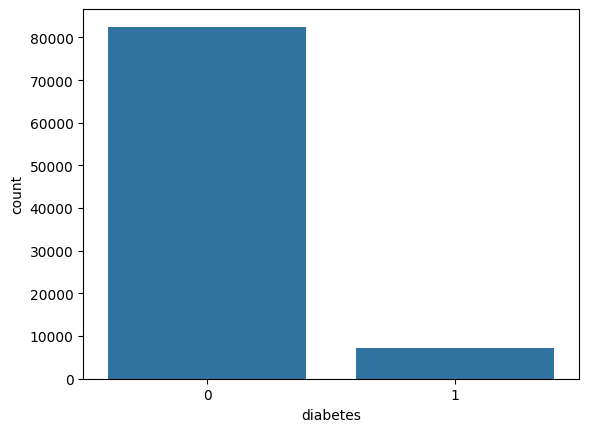

In [53]:
sns.countplot(data=df_encoded, x='diabetes')

<small> There's a clear imbalance in the sampling of the target variable 'diabetes', with a significantly higher number of non-diabetic cases compared to diabetic cases. This class imbalance could potentially impact the performance of machine learning models trained on this data, as they may become biased towards the majority class.</small>

### Splitting Data

In [54]:
pip install imblearn

Note: you may need to restart the kernel to use updated packages.


In [55]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

In [56]:
# features
X = df_encoded.drop('diabetes', axis=1)
#target
y = df_encoded['diabetes']

# Stratified split first
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Apply SMOTE only to training set
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)


<small> Verify better balance in y_train_smote </small>

<Axes: xlabel='diabetes', ylabel='count'>

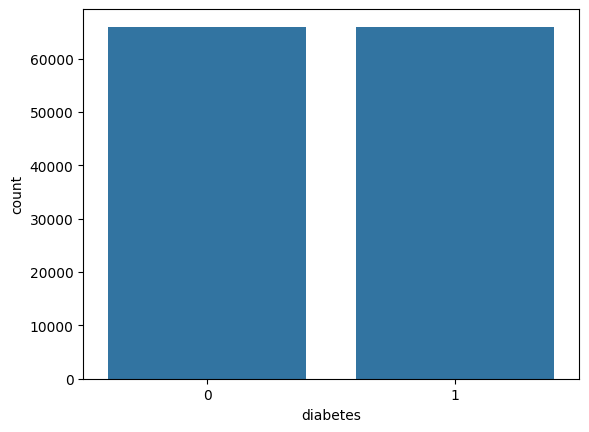

In [57]:
sns.countplot(x=y_train_smote)

### Scaling

In [58]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

<small>Before scaling </small>

In [59]:
print("Old Scale: ")
print(np.min(X_train_smote)," <-> " ,np.max(X_train_smote))

Old Scale: 
0.0  <->  300.0


In [60]:
# scale only the features (this helps with convergence for some models)
X_train_scaled = scaler.fit_transform(X_train_smote)

X_test_scaled = scaler.transform(X_test)

<small> After Scaling </small>

In [61]:
print("New Scale:")
print(np.min(X_train_scaled)," <-> " ,np.max(X_train_scaled))

New Scale:
-2.7338364213090207  <->  6.260382548209328


### Using Classifiers

In [62]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

Logistic Regression

In [63]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression()
log_reg.fit(X_train_scaled, y_train_smote)

y_pred_log = log_reg.predict(X_test_scaled)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print("\nClassification Report:\n", classification_report(y_test, y_pred_log))

Logistic Regression Accuracy: 0.8939655652755335

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.90      0.94     16505
           1       0.42      0.81      0.55      1442

    accuracy                           0.89     17947
   macro avg       0.70      0.86      0.75     17947
weighted avg       0.94      0.89      0.91     17947



K-Nearest Neighbors (KNN)

In [64]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train_smote)

y_pred_knn = knn.predict(X_test_scaled)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("\nClassification Report:\n", classification_report(y_test, y_pred_knn))

KNN Accuracy: 0.9260600657491502

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.94      0.96     16505
           1       0.53      0.72      0.61      1442

    accuracy                           0.93     17947
   macro avg       0.75      0.83      0.78     17947
weighted avg       0.94      0.93      0.93     17947



Support Vector Machine (SVM)

In [65]:
from sklearn.svm import SVC

# Initialize and Train (Using RBF kernel for non-linearity)
svm = SVC(kernel='rbf', random_state=42)
svm.fit(X_train_scaled, y_train_smote)

y_pred_svm = svm.predict(X_test_scaled)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.9275644954588511

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.94      0.96     16505
           1       0.53      0.77      0.63      1442

    accuracy                           0.93     17947
   macro avg       0.76      0.86      0.80     17947
weighted avg       0.94      0.93      0.93     17947



Decision Trees

In [66]:
from sklearn.tree import DecisionTreeClassifier


# Note: We use unscaled data because decision trees don't require scaling
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_smote, y_train_smote)

# Predict
y_pred_dt = dt.predict(X_test)

# Evaluate
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.9470106424472057

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.97      0.97     16505
           1       0.66      0.70      0.68      1442

    accuracy                           0.95     17947
   macro avg       0.82      0.83      0.83     17947
weighted avg       0.95      0.95      0.95     17947



Random Forest

In [67]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_smote, y_train_smote)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.9644508831559592

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.99      0.98     16505
           1       0.85      0.67      0.75      1442

    accuracy                           0.96     17947
   macro avg       0.91      0.83      0.87     17947
weighted avg       0.96      0.96      0.96     17947



Naive Bayes

In [68]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train_smote, y_train_smote)

y_pred_nb = nb.predict(X_test)

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.6737059118515629

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.65      0.79     16505
           1       0.19      0.96      0.32      1442

    accuracy                           0.67     17947
   macro avg       0.59      0.81      0.55     17947
weighted avg       0.93      0.67      0.75     17947



/var/folders/pc/qpl83vwd53v_hm0hj90d3nz00000gn/T/ipykernel_1857/817703230.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Accuracy', y='Model', data=results_df, palette='viridis')


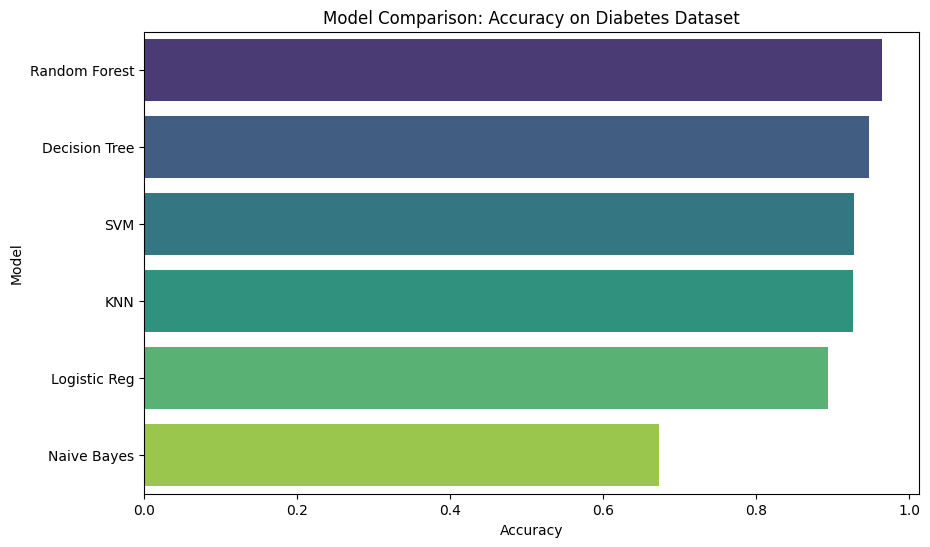

In [69]:
models = ['Logistic Reg', 'KNN', 'SVM', 'Decision Tree', 'Random Forest', 'Naive Bayes']
accuracies = [
    accuracy_score(y_test, y_pred_log),
    accuracy_score(y_test, y_pred_knn),
    accuracy_score(y_test, y_pred_svm),
    accuracy_score(y_test, y_pred_dt),
    accuracy_score(y_test, y_pred_rf),
    accuracy_score(y_test, y_pred_nb)
]

results_df = pd.DataFrame({'Model': models, 'Accuracy': accuracies})
results_df = results_df.sort_values(by='Accuracy', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Accuracy', y='Model', data=results_df, palette='viridis')
plt.title('Model Comparison: Accuracy on Diabetes Dataset')
plt.xlabel('Accuracy')
plt.show()